# Modeling

## 1. Imports

In [71]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

## 2. Obtener data

In [72]:
df = pd.read_csv('../data/processed/train_processed.csv')

In [73]:
df.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Lag_4,Rolling_4
0,2015-02-01,2527.914,3092.544,4130.533,4619.108,304.508,3036.67325
1,2015-02-08,968.534,2527.914,3092.544,4130.533,4619.108,3592.52475
2,2015-02-15,2771.054,968.534,2527.914,3092.544,4130.533,2679.88125
3,2015-02-22,224.912,2771.054,968.534,2527.914,3092.544,2340.01150
4,2015-03-01,2289.643,224.912,2771.054,968.534,2527.914,1623.10350


In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Order Date  205 non-null    str    
 1   Sales       205 non-null    float64
 2   Lag_1       205 non-null    float64
 3   Lag_2       205 non-null    float64
 4   Lag_3       205 non-null    float64
 5   Lag_4       205 non-null    float64
 6   Rolling_4   205 non-null    float64
dtypes: float64(6), str(1)
memory usage: 11.3 KB


Pequeña transformación de Order Date a datetime

In [75]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%Y-%m-%d')

In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order Date  205 non-null    datetime64[us]
 1   Sales       205 non-null    float64       
 2   Lag_1       205 non-null    float64       
 3   Lag_2       205 non-null    float64       
 4   Lag_3       205 non-null    float64       
 5   Lag_4       205 non-null    float64       
 6   Rolling_4   205 non-null    float64       
dtypes: datetime64[us](1), float64(6)
memory usage: 11.3 KB


## 3. Modeling

### 3.1 Modelos ML

Diccionario para contener todos los modelos que queremos utilizar.

In [77]:
models_dict = {
    'NaiveModel': None,
    'LinearRegression': LinearRegression(),
    'RandomForestRegressor': RandomForestRegressor(random_state=42),
    'XGBRegressor': XGBRegressor(),
    'LGBMRegressor': LGBMRegressor(random_state=42, verbose=-1)
}

### 3.2 Separación de X e y

In [78]:
X = df.drop(columns=['Order Date', 'Sales'])
y = df['Sales']

### 3.3 TimeSeriesSplit y evaluar modelos

En este punto lo que pasa es lo siguiente:

Todos los modelos funcionan diferente dependiendo de cuantas semanas tienen para entrenar y cuanto es el test. Por lo que se aplicará TimeSeriesSplit, en donde en n_split=5 es que hará 5 pruebas diferentes, cada una ocupa 10 semanas de test, si tenemos 200 semanas, primero prueba con 150 semanas de train y 10 semanas siguientes de test (serían 160 semanas en total, no toma las otras 40), luego 160 semanas train y 10 de test y asi sucesivamente hasta 190 de train y 10 de test, completando 5 pruebas en total.

Ahora, al ocupar el objeto TimeSeriesSplit y hacerle split a nuestro conjunto de X, va a hacer las 5 separaciones. El _**for**_ de eso entra primero al primer fold, 150 semanas train y 10 test (máximo llega a la semana 160), entonces el train_idx lo único que obtiene son los índices de las 150 semanas, 0,1,2,3,4...149 y test_idx obtiene los índices de las 10 semanas siguientes.

De esa forma en X (features) buscamos los registros del 0 al 149 que seran para el entrenamiento y los del 150 al 159 para el test.

Luego lo mismo para el target (Sales) obtenemos las respuestas para el entrenamiento del 0 al 149, luego las respuestas del 150 al 159.

Luego se entrena el primer modelo del diccionario, se predicen el test y se calcula MAE y RMSE para cada fold, agregando a la lista cada uno de los resultados de los folds con distinto tiempo.

Después al dicicionario se agrega un diccionario con el modelo trabajado, promedio y desviación estandar de MAE y RMSE.

In [79]:
tscv = TimeSeriesSplit(n_splits=5, test_size=10)  # 5 folds, cada uno con 10 semanas de test

resultados_cv = []

for name, model in models_dict.items():
    maes = []
    rmses = []

    # Lógica para el modelo ingenuo, en cada split obtenemos las ventas reales y ventas de la semana pasada, calculamos rendimiento en base a eso
    if model==None:
        for train_idx, test_idx in tscv.split(X):
            y_test = y.iloc[test_idx]
            # Primero desplazamos los resultados 1 hacia abajo para que tenga las ventas de la semana pasada
            y_pred = y.shift(1).iloc[test_idx]

            mae = mean_absolute_error(y_test, y_pred)
            rmse = root_mean_squared_error(y_test, y_pred)

            maes.append(mae)
            rmses.append(rmse)

        resultados_cv.append({
            'modelo': 'NaiveModel',
            'MAE_promedio': np.mean(maes),
            'MAE_std': np.std(rmses),
            'RMSE_promedio': np.mean(rmses),
            'RMSE_std': np.std(rmses)
        })

    # Lógica para el resto de modelos
    else:
        for train_idx, test_idx in tscv.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            
            maes.append(mean_absolute_error(y_test, y_pred))
            rmses.append(root_mean_squared_error(y_test, y_pred))
    
        resultados_cv.append({
            'modelo': name,
            'MAE_promedio': np.mean(maes),
            'MAE_std': np.std(maes),
            'RMSE_promedio': np.mean(rmses),
            'RMSE_std': np.std(rmses)
        })

df_cv = pd.DataFrame(resultados_cv)
df_cv

,modelo,MAE_promedio,MAE_std,RMSE_promedio,RMSE_std
0,NaiveModel,5879.237372,1528.294751,7042.670827,1528.294751
1,LinearRegression,5006.014393,1723.396191,6289.540709,2026.298355
2,RandomForestRegressor,5149.959244,1494.699355,6565.963648,1555.038242
3,XGBRegressor,5035.546675,940.517252,6759.044872,1212.511664
4,LGBMRegressor,5090.406756,1055.740278,6306.521172,1126.875540


## 4. Visualizar resultados

In [80]:
stats_columns_names = df_cv.drop(columns=['modelo']).columns

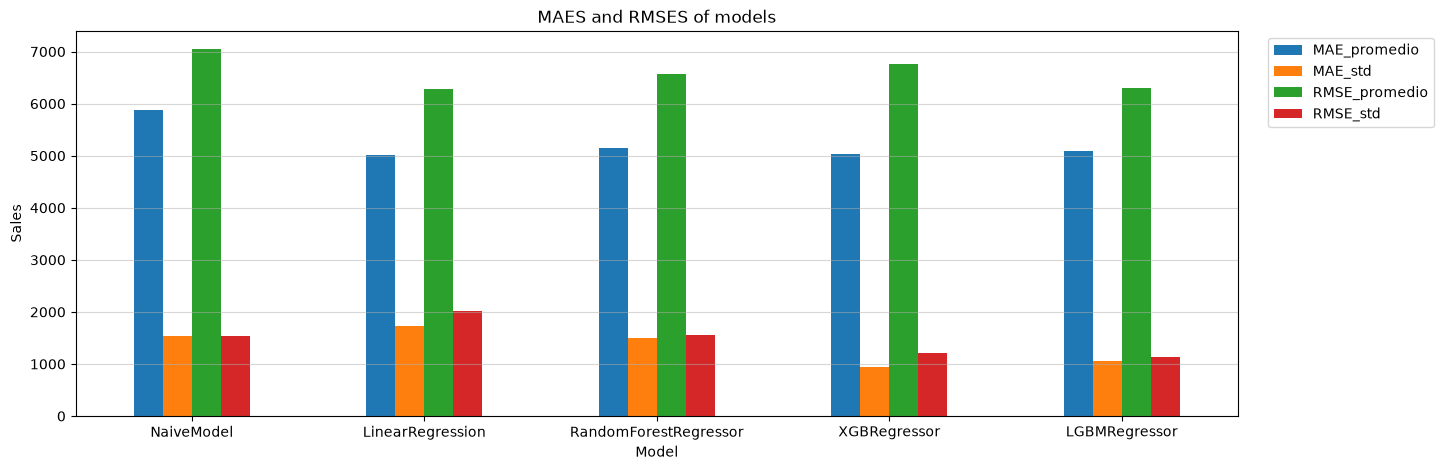

In [88]:
ax = df_cv.plot(
    kind='bar',
    x='modelo',
    y=stats_columns_names,
    figsize=(15, 5)
)

plt.title('MAES and RMSES of models')
plt.xlabel('Model')
plt.ylabel('Sales')

# Ajustar grid de forma manual
ax.grid(
    axis='y',
    alpha=0.5
)

ax.legend(bbox_to_anchor=(1.02, 1))

plt.tick_params(rotation=0)